# Retail Sales & Profitability Intelligence Dashboard

##### This project analyzes retail sales data to generate insights on revenue and profitability, and presents them through an interactive dashboard to support better business decision-making.

In [95]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px

In [96]:
#load the dataset
df = pd.read_excel('C:\\Users\\Diya Kolay\\Downloads\\Superstore.xlsx')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [97]:
#number of rows and columns
df.shape

(9994, 21)

In [98]:
#list of all columns name
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [99]:
#shows dtype 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [100]:
#basic statistics 
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2013-04-30 19:20:02.401441024,2013-05-04 18:20:49.229537792,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2011-01-04 00:00:00,2011-01-08 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2012-05-23 00:00:00,2012-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2013-06-27 00:00:00,2013-06-30 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2014-05-15 00:00:00,2014-05-19 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2014-12-31 00:00:00,2015-01-06 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [101]:
#to check null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### convert dates

In [102]:
#convert datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [103]:
#extract year and month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [104]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2013,11


### create KPIs

In [105]:
#total sales
total_sales = df['Sales'].sum()
print(total_sales)

2297200.8603000003


In [106]:
#total profit
total_profit = df['Profit'].sum()
print(total_profit)

286397.0216999999


In [107]:
#profit margin
profit_margin = (total_profit / total_sales) * 100
print(profit_margin)

#for every 100 inr of sale , the store earns 12.46 inr as profit

12.4672172403156


### check correlation

In [108]:
#select numeric columns only
numeric_df = df.select_dtypes(include=['number'])
print(numeric_df)

      Row ID  Postal Code     Sales  Quantity  Discount    Profit  Year  Month
0          1        42420  261.9600         2      0.00   41.9136  2013     11
1          2        42420  731.9400         3      0.00  219.5820  2013     11
2          3        90036   14.6200         2      0.00    6.8714  2013      6
3          4        33311  957.5775         5      0.45 -383.0310  2012     10
4          5        33311   22.3680         2      0.20    2.5164  2012     10
...      ...          ...       ...       ...       ...       ...   ...    ...
9989    9990        33180   25.2480         3      0.20    4.1028  2011      1
9990    9991        92627   91.9600         2      0.00   15.6332  2014      2
9991    9992        92627  258.5760         2      0.20   19.3932  2014      2
9992    9993        92627   29.6000         4      0.00   13.3200  2014      2
9993    9994        92683  243.1600         2      0.00   72.9480  2014      5

[9994 rows x 8 columns]


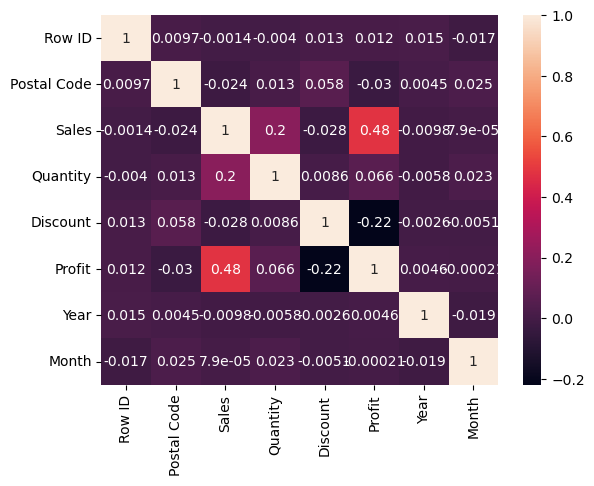

In [109]:
#correlation heatmap
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

### Exploratory data analysis

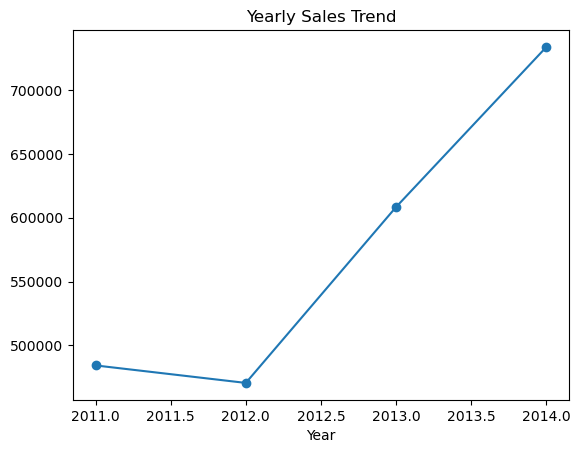

In [110]:
#sales trend over time


#group by year
yearly_sales = df.groupby('Year')['Sales'].sum()

#plot
yearly_sales.plot(kind='line', marker='o')
plt.title("Yearly Sales Trend")
plt.show()

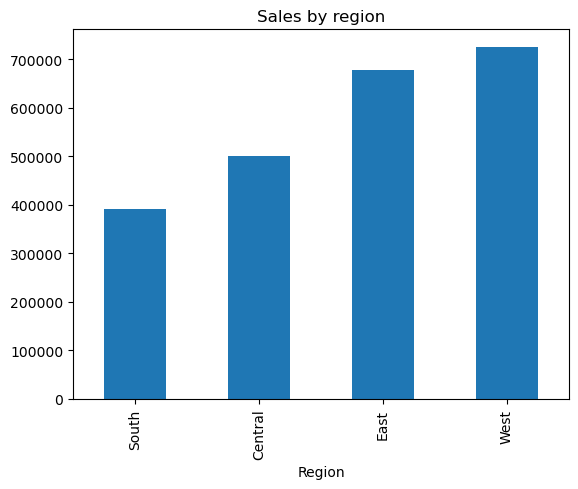

In [111]:
#region-wise analysis

region_sales = df.groupby ('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='bar')
plt.title("Sales by region")
plt.show()

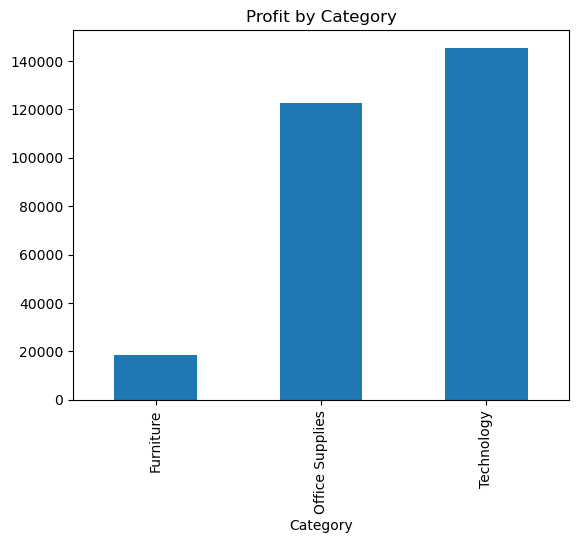

In [112]:
#category & sub-category 
category_profit = df.groupby('Category')['Profit'].sum()

#plot
category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

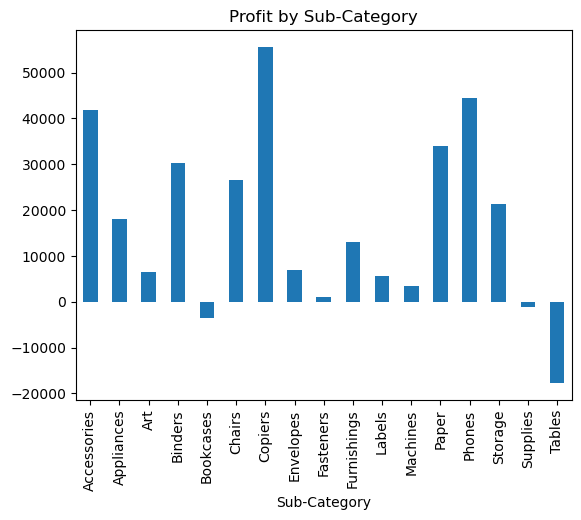

In [113]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum()

#plot
subcategory_profit.plot(kind='bar')
plt.title("Profit by Sub-Category")
plt.show()

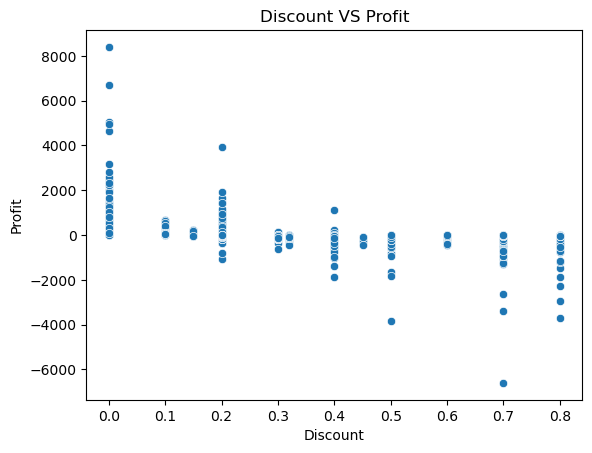

In [114]:
#discount impact

sns.scatterplot(x='Discount', y='Profit', data = df)
plt.title("Discount VS Profit")
plt.show()

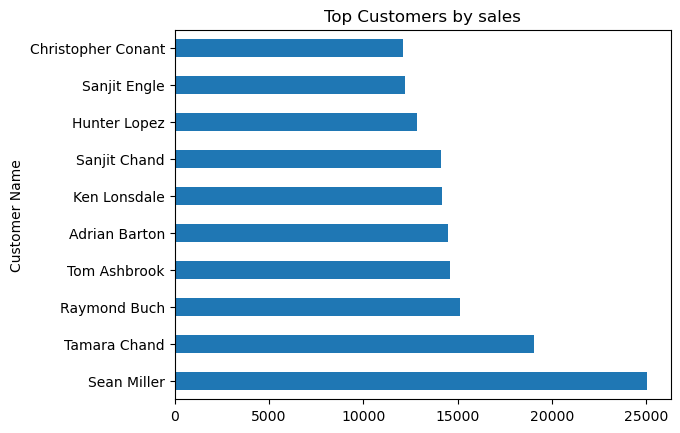

In [115]:
#top customer

top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

#plot
top_customers.plot(kind='barh')
plt.title("Top Customers by sales")
plt.show()

In [116]:
#shipping analysis
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Shipping Days'].mean()

3.958875325195117

In [117]:
#loss making products

loss_products = df[df['Profit'] < 0]

loss_products[['Product Name', 'Sales', 'Profit']].sort_values(by='Profit').head(10)

,Product Name,Sales,Profit
7772,Cubify CubeX 3D Printer Double Head Print,4499.985,-6599.9780
683,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
9774,GBC DocuBind P400 Electric Binding System,2177.584,-3701.8928
3011,Lexmark MX611dhe Monochrome Laser Printer,2549.985,-3399.9800
4991,Ibico EPK-21 Electric Binding System,1889.990,-2929.4845
3151,Cubify CubeX 3D Printer Double Head Print,1799.994,-2639.9912
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,-2287.7820
9639,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,-1862.3124
1199,GBC DocuBind P400 Electric Binding System,1088.792,-1850.9464
2697,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784


In [118]:
#customer segmentation 

from sklearn.cluster import KMeans

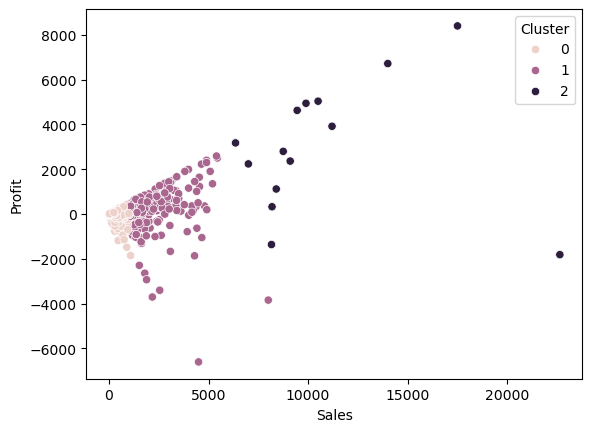

In [119]:
#use relevant features
X = df[['Sales', 'Profit']]

kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(X)

sns.scatterplot(x='Sales', y='Profit', hue='Cluster', data=df)
plt.show()


In [120]:
#month-wise sales
df['Year_Month'] = df['Order Date'].dt.to_period('M')

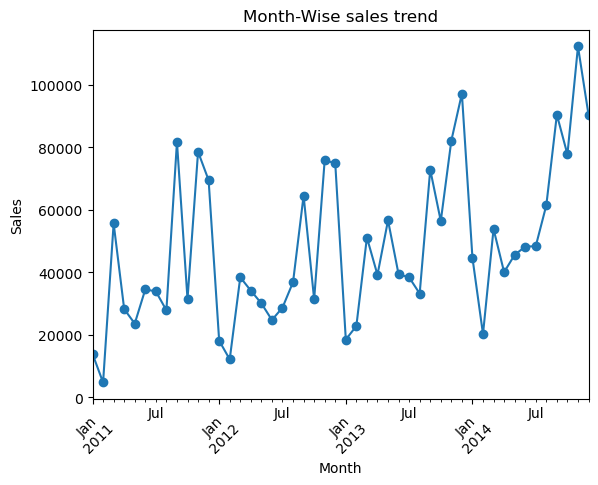

In [121]:
monthly_sales = df.groupby('Year_Month')['Sales'].sum()

#plot
monthly_sales.plot(kind='line', marker='o')
plt.title("Month-Wise sales trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

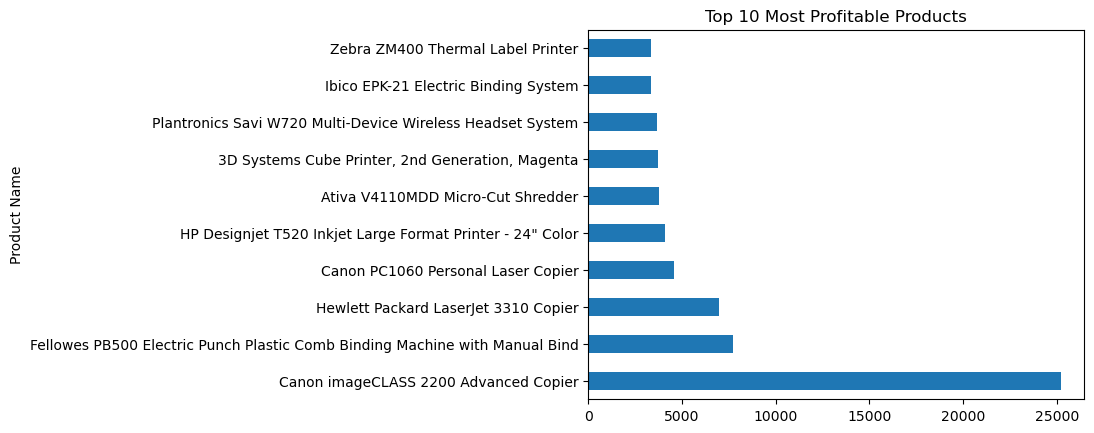

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [122]:
top_profit_product = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

top_profit_product.plot(kind='barh')
plt.title("Top 10 Most Profitable Products")
plt.show()

print(top_profit_product)

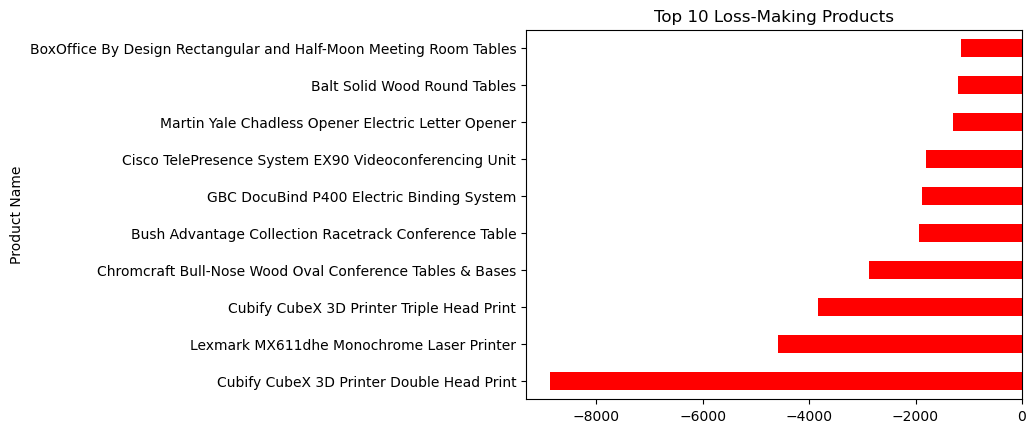

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


In [123]:
loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

loss_products.plot(kind='barh', color='red')
plt.title("Top 10 Loss-Making Products")
plt.show()

print(loss_products)

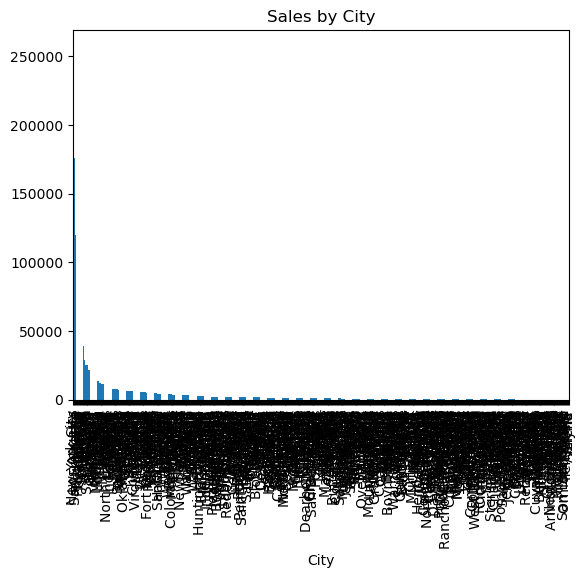

City
New York City    256368.161
Los Angeles      175851.341
Seattle          119540.742
San Francisco    112669.092
Philadelphia     109077.013
                    ...    
Ormond Beach          2.808
Pensacola             2.214
Jupiter               2.064
Elyria                1.824
Abilene               1.392
Name: Sales, Length: 531, dtype: float64


In [124]:
cities_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)

cities_sales.plot(kind='bar')
plt.title("Sales by City")
plt.show()

print(cities_sales)

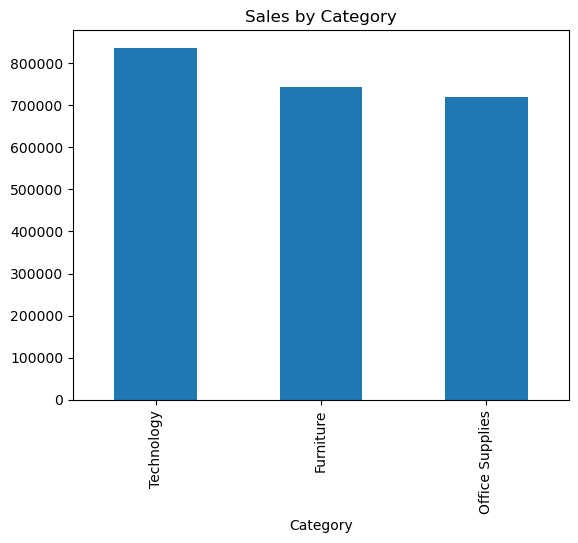

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [125]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

print(category_sales)

In [126]:
category_quantity = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

print(category_quantity)

Category
Office Supplies    22906
Furniture           8028
Technology          6939
Name: Quantity, dtype: int64


C:\Users\Diya Kolay\AppData\Local\Temp\ipykernel_24588\2100733536.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby('Discount Range')['Profit'].mean()


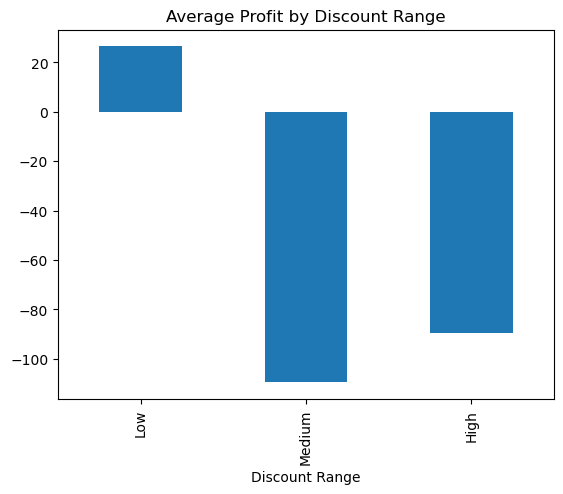

Discount Range
Low        26.501571
Medium   -109.528873
High      -89.438144
Name: Profit, dtype: float64


In [127]:
# Create bins for discount ranges
df['Discount Range'] = pd.cut(df['Discount'], bins=[0, 0.2, 0.5, 1], 
                             labels=['Low', 'Medium', 'High'])

discount_profit = df.groupby('Discount Range')['Profit'].mean()

discount_profit.plot(kind='bar')
plt.title("Average Profit by Discount Range")
plt.show()

print(discount_profit)

In [128]:
discount_category = df.groupby(['Category', 'Discount Range'])['Profit'].mean().unstack()

print(discount_category)

Discount Range         Low      Medium        High
Category                                          
Furniture        19.913799 -114.751058  -64.311076
Office Supplies  17.647646         NaN  -69.323732
Technology       55.592752  -95.802995 -851.274743


C:\Users\Diya Kolay\AppData\Local\Temp\ipykernel_24588\2576672159.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_category = df.groupby(['Category', 'Discount Range'])['Profit'].mean().unstack()


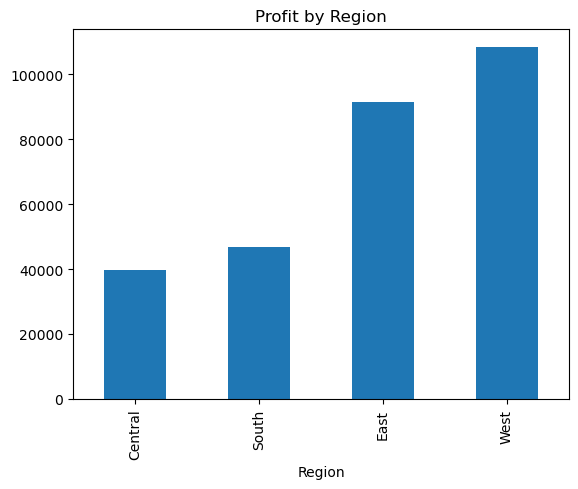

In [129]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()

region_profit.plot(kind='bar')
plt.title("Profit by Region")
plt.show()

In [130]:
summary = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
})

print(summary)

                       Sales       Profit  Quantity  Discount
Category                                                     
Furniture        741999.7953   18451.2728      8028  0.173923
Office Supplies  719047.0320  122490.8008     22906  0.157285
Technology       836154.0330  145454.9481      6939  0.132323


In [131]:
# Calculate shipping time
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Avg shipping time by Ship Mode
ship_mode_efficiency = df.groupby('Ship Mode')['Ship Days'].mean().sort_values()

print(ship_mode_efficiency)

Ship Mode
Same Day          0.044199
First Class       2.182055
Second Class      3.240103
Standard Class    5.007205
Name: Ship Days, dtype: float64


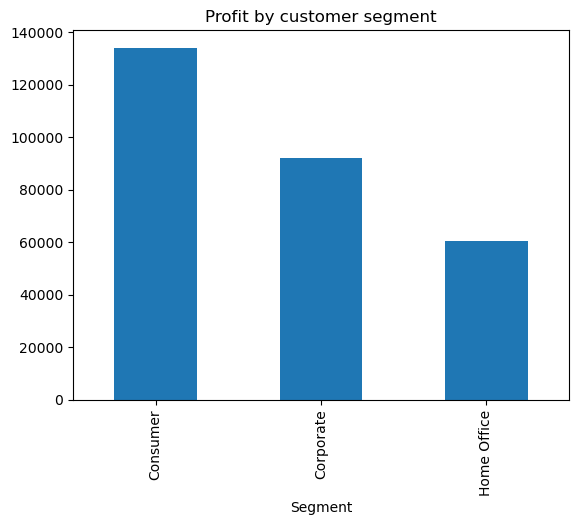

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


In [132]:
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

segment_profit.plot(kind='bar')
plt.title("Profit by customer segment")
plt.show()

print(segment_profit)

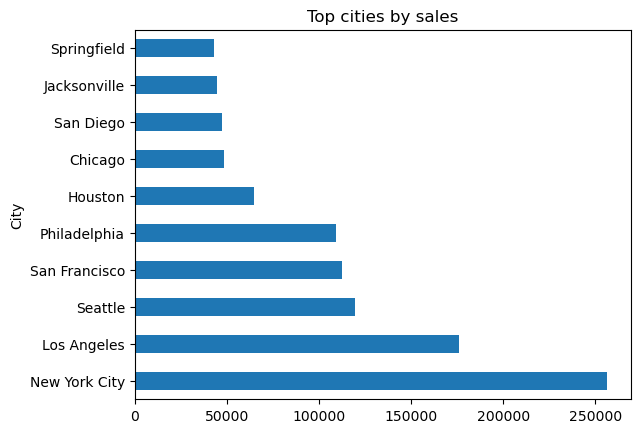

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


In [133]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind='barh')
plt.title("Top cities by sales")
plt.show()

print(top_cities)

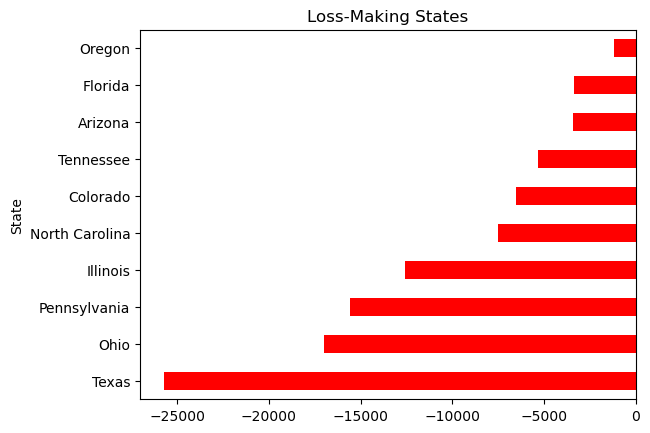

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64


In [134]:
state_profit = df.groupby('State')['Profit'].sum().sort_values()

loss_states = state_profit.head(10)

loss_states.plot(kind='barh', color='red')
plt.title("Loss-Making States")
plt.show()

print(loss_states)

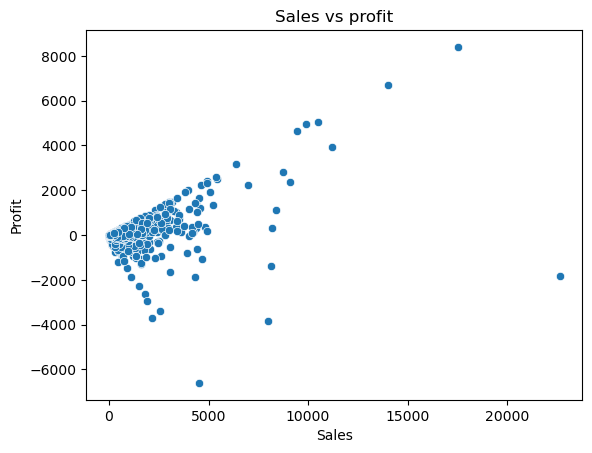

In [135]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs profit")
plt.show()

In [136]:
subcat_analysis = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Sales', ascending=False)

print(subcat_analysis)

                    Sales      Profit
Sub-Category                         
Phones        330007.0540  44515.7306
Chairs        328449.1030  26590.1663
Storage       223843.6080  21278.8264
Tables        206965.5320 -17725.4811
Binders       203412.7330  30221.7633
Machines      189238.6310   3384.7569
Accessories   167380.3180  41936.6357
Copiers       149528.0300  55617.8249
Bookcases     114879.9963  -3472.5560
Appliances    107532.1610  18138.0054
Furnishings    91705.1640  13059.1436
Paper          78479.2060  34053.5693
Supplies       46673.5380  -1189.0995
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Labels         12486.3120   5546.2540
Fasteners       3024.2800    949.5182


In [137]:
customer_orders = df.groupby('Customer ID')['Order ID'].nunique()

repeat_customers = customer_orders[customer_orders > 1].count()
one_time_customers = customer_orders[customer_orders == 1].count()

print("Repeat:", repeat_customers)
print("One-time:", one_time_customers)

Repeat: 781
One-time: 12


In [138]:
df['Profit Margin'] = df['Profit'] / df['Sales']

category_margin = df.groupby('Category')['Profit Margin'].mean()

print(category_margin)

Category
Furniture          0.038784
Office Supplies    0.138030
Technology         0.156138
Name: Profit Margin, dtype: float64


In [139]:
discount_effect = df.groupby(['Category'])[['Discount', 'Profit']].mean()

print(discount_effect)

                 Discount     Profit
Category                            
Furniture        0.173923   8.699327
Office Supplies  0.157285  20.327050
Technology       0.132323  78.752002


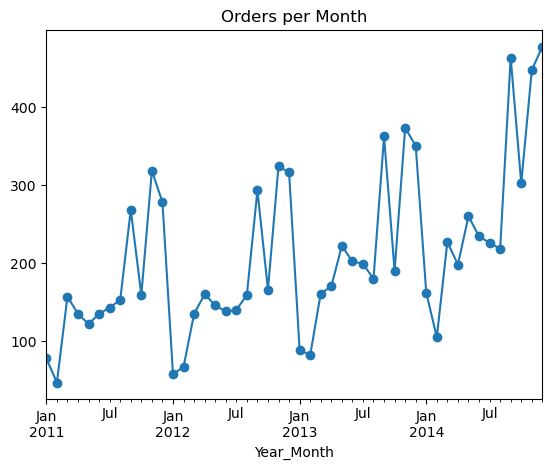

In [140]:
monthly_orders = df.groupby('Year_Month')['Order ID'].count()

monthly_orders.plot(kind='line', marker='o')
plt.title("Orders per Month")
plt.show()

In [141]:
summary = {
    "Top Months": monthly_sales.head(3),
    "Loss Products": loss_products.shape[0],
    "Worst Region": region_profit.idxmin(),
    "Best Segment": segment_profit.idxmax(),
    
}

print(summary)

{'Top Months': Year_Month
2011-01    13946.229
2011-02     4810.558
2011-03    55691.009
Freq: M, Name: Sales, dtype: float64, 'Loss Products': 10, 'Worst Region': 'Central', 'Best Segment': 'Consumer'}


In [142]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_discount = df['Discount'].mean()
total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Avg Discount:", avg_discount)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603000003
Total Profit: 286397.0216999999
Avg Discount: 0.15620272163297977
Total Orders: 5009
